DEVICE: cuda
Class counts (train/val/test): [ 828  496 1245] [266 108 269] [264 143 396]
TOTAL TRIALS: 1350
Class weights: [0.89970802 1.50193194 0.59836003]
[PASS1] Start fresh
[PASS1 001/1350] best_val_bacc=0.3569 best_val_loss=1.0935 params={'hidden': (64, 32), 'dropout': 0.0, 'lr': 0.001, 'weight_decay': 0.0, 'batch_size': 64}
[PASS1 002/1350] best_val_bacc=0.3594 best_val_loss=1.0941 params={'hidden': (64, 32), 'dropout': 0.0, 'lr': 0.001, 'weight_decay': 0.0, 'batch_size': 128}
[PASS1 003/1350] best_val_bacc=0.3519 best_val_loss=1.0883 params={'hidden': (64, 32), 'dropout': 0.0, 'lr': 0.001, 'weight_decay': 0.0, 'batch_size': 256}
[PASS1 004/1350] best_val_bacc=0.3798 best_val_loss=1.0965 params={'hidden': (64, 32), 'dropout': 0.0, 'lr': 0.001, 'weight_decay': 1e-05, 'batch_size': 64}
[PASS1 005/1350] best_val_bacc=0.3450 best_val_loss=1.1003 params={'hidden': (64, 32), 'dropout': 0.0, 'lr': 0.001, 'weight_decay': 1e-05, 'batch_size': 128}
[PASS1] checkpoint saved (next=6)
[PASS1

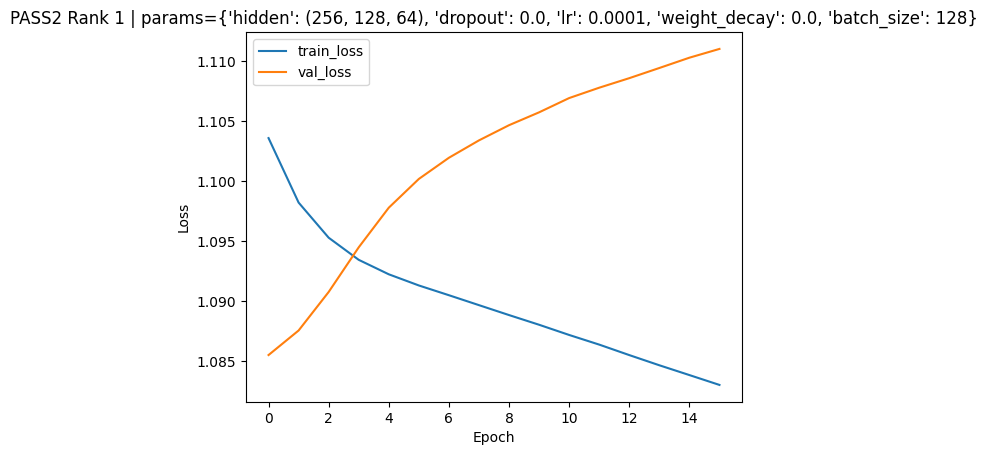

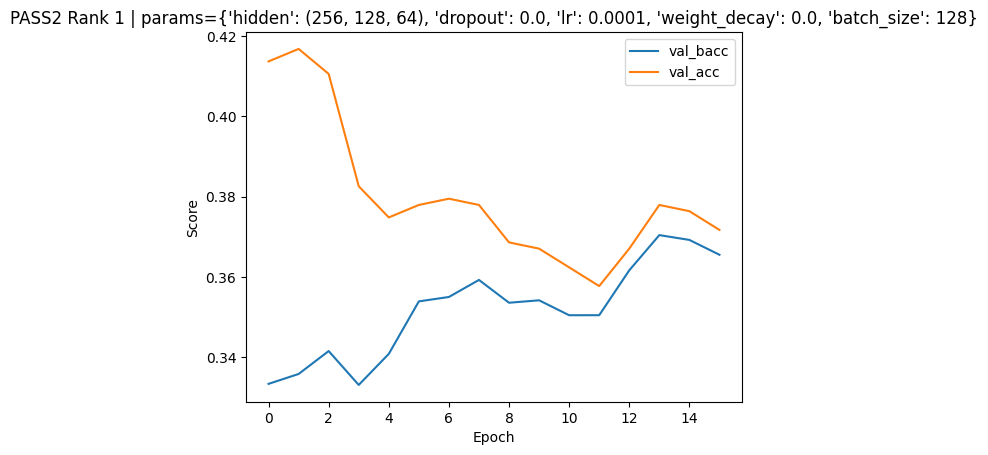

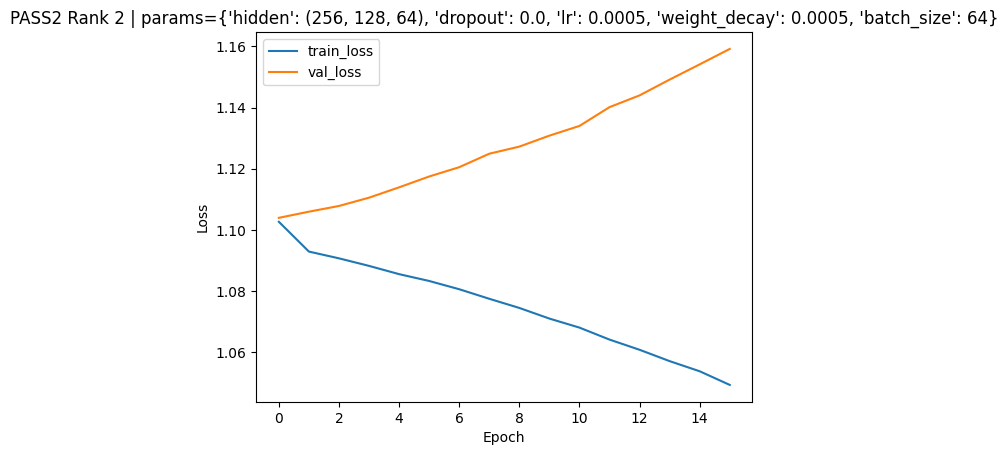

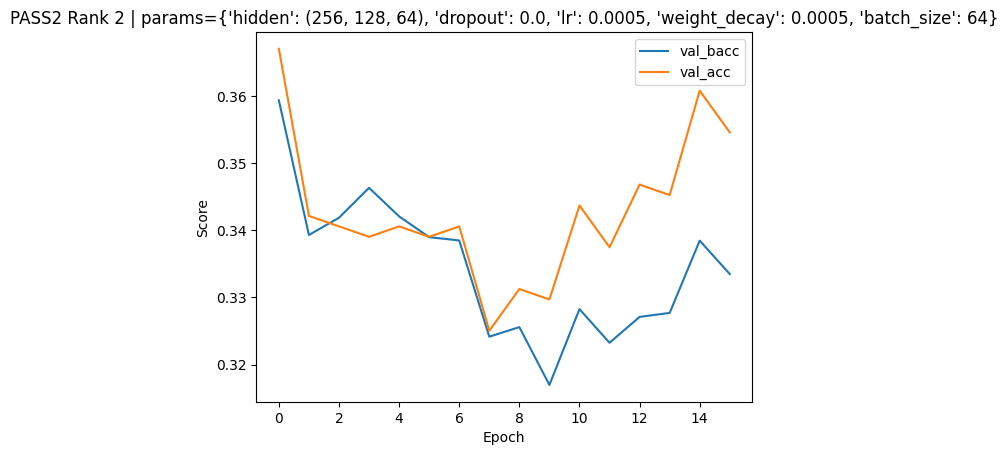

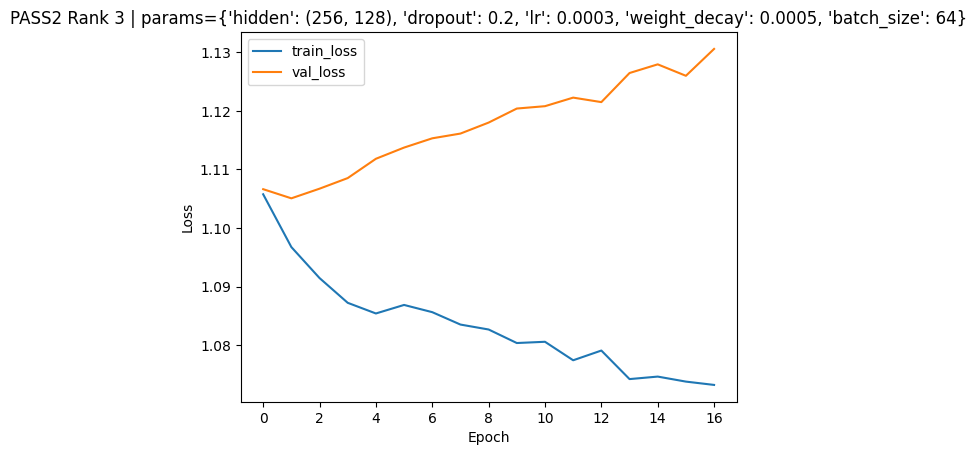

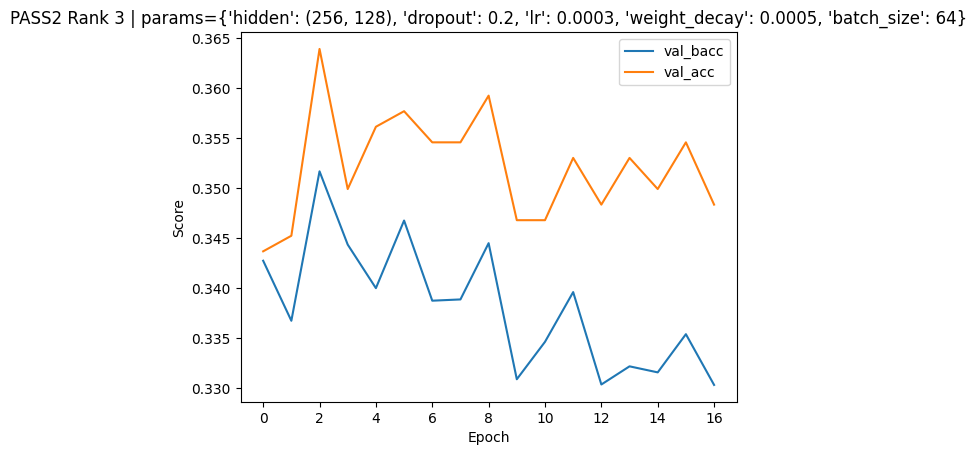

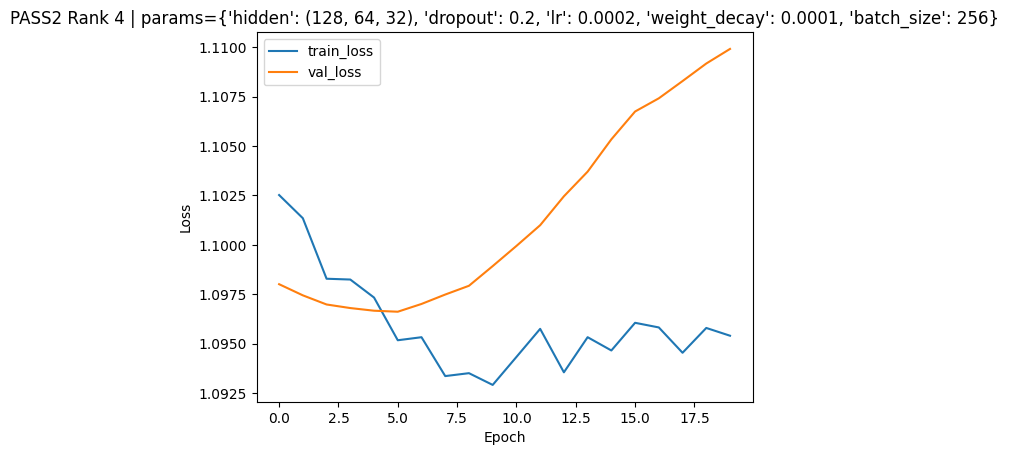

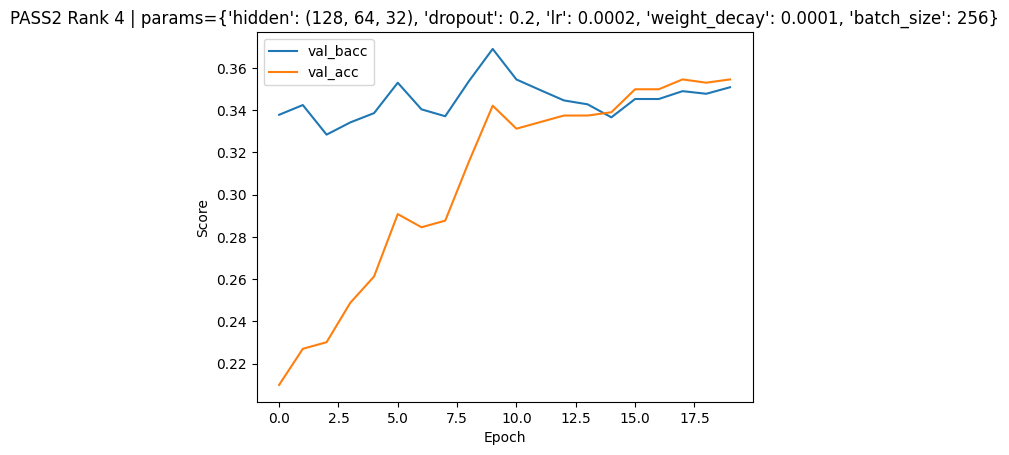

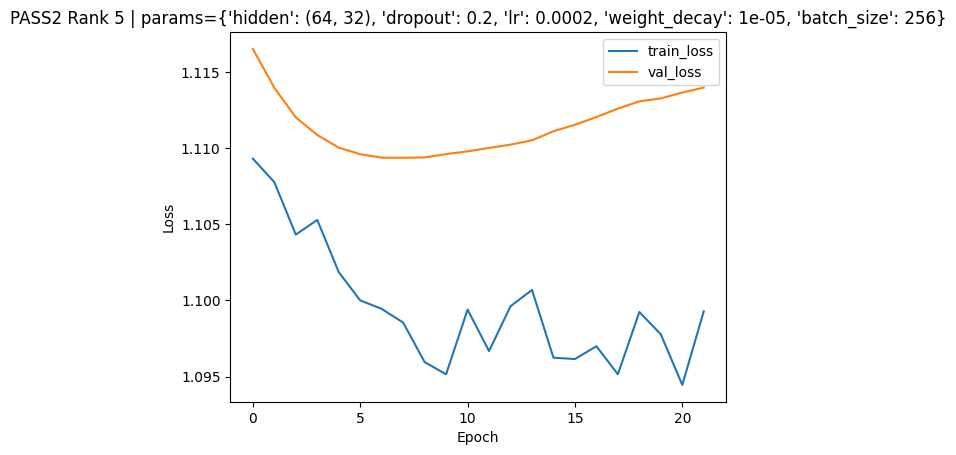

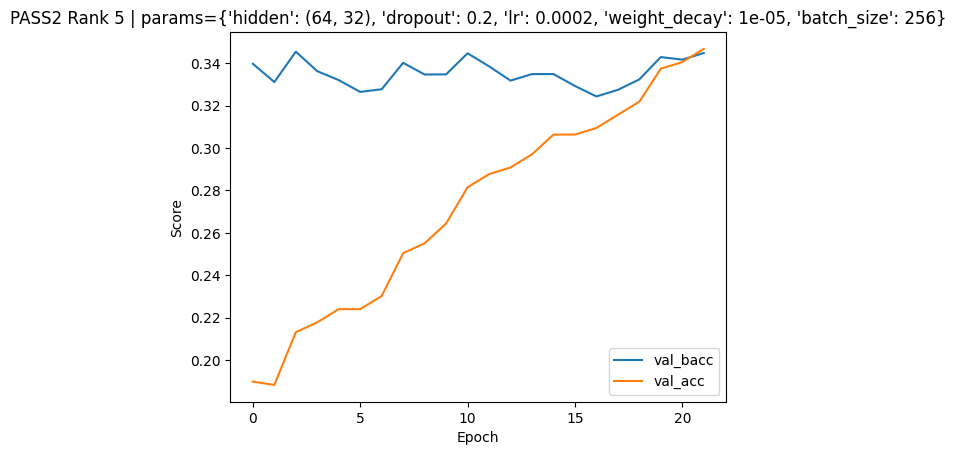

Pred distribution: [203 252 348]
True distribution: [264 143 396]

===== PASS2 BEST MLP (7-day ahead) TEST =====

Confusion Matrix (rows=true, cols=pred):
[[ 69  83 112]
 [ 36  48  59]
 [ 98 121 177]]

Accuracy: 0.36612702366127026
Balanced Accuracy: 0.34799922299922303

Per-class PR/RC/F1:
  0 (Down): P=0.340 R=0.261 F1=0.296 Support=264
  1 (Sideway): P=0.190 R=0.336 F1=0.243 Support=143
  2 (Up): P=0.509 R=0.447 F1=0.476 Support=396

Macro Avg: P=0.346 R=0.348 F1=0.338


In [1]:
import os
import pickle
import itertools
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, accuracy_score, balanced_accuracy_score,
    precision_recall_fscore_support
)

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import matplotlib.pyplot as plt

# ============================================================
# Config
# ============================================================
CSV_PATH = "../CLASSIFY-SnP_daily_update_AMZN_features_with_target.csv"
FEATURES = ["ma_gap_20", "vol_10", "vol_20", "lower_wick", "upper_wick", "ret_1", "range_pct", "co_ret", "ret_5"]

TRAIN_RATIO = 0.8
VAL_RATIO_IN_TRAIN = 0.2

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# ----- Label -----
HORIZON = 7
PRICE_COL_CANDIDATES = ["Close", "Adj Close", "close", "adj_close"]
SIDEWAY_THRESHOLD = 0.01
CLASS_LABELS = {0: "Down", 1: "Sideway", 2: "Up"}

# ----- Device / Loader -----
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

BATCH_SIZE_TEST = 256

# Windows + Jupyter แนะนำ 0 หรือ 2 (เริ่มที่ 2 ถ้าไม่ค้าง)
NUM_WORKERS = 2
PIN_MEMORY = True

# ----- Pass-1 (ค้นหา Top-5 แบบเร็ว/ประหยัด) -----
PASS1_EPOCHS = 30          # เทรนสั้น ๆ เพื่อคัดกรอง
PASS1_PATIENCE = 7
PASS1_MIN_DELTA = 1e-4
PASS1_EARLY_STOP_METRIC = "val_loss"
SELECT_BEST_METRIC = "val_bacc"   # เลือก best trial ด้วย balanced accuracy

# ----- Pass-2 (จัดเต็มเฉพาะ Top-5) -----
PASS2_EPOCHS = 200
PASS2_PATIENCE = 15
PASS2_MIN_DELTA = 1e-4
PASS2_EARLY_STOP_METRIC = "val_loss"

TOP_K = 5

# ----- Checkpoints -----
CKPT_PASS1 = "ckpt_pass1_trials.pkl"
CKPT_PASS2 = "ckpt_pass2_top5.pkl"
SAVE_EVERY_TRIALS = 5

# ============================================================
# Helpers
# ============================================================
def eval_report(name, y_true, y_pred, K=3):
    print(f"\n===== {name} =====")
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(K))
    print("\nConfusion Matrix (rows=true, cols=pred):")
    print(cm)

    acc = accuracy_score(y_true, y_pred)
    bacc = balanced_accuracy_score(y_true, y_pred)
    pr, rc, f1, sup = precision_recall_fscore_support(
        y_true, y_pred, labels=np.arange(K), zero_division=0
    )
    macro_pr, macro_rc, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )

    print("\nAccuracy:", acc)
    print("Balanced Accuracy:", bacc)
    print("\nPer-class PR/RC/F1:")
    for c in range(K):
        print(f"  {c} ({CLASS_LABELS[c]}): P={pr[c]:.3f} R={rc[c]:.3f} F1={f1[c]:.3f} Support={sup[c]}")
    print(f"\nMacro Avg: P={macro_pr:.3f} R={macro_rc:.3f} F1={macro_f1:.3f}")

def evaluate_loader_loss_acc(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            total_loss += loss.item() * xb.size(0)

            pred = torch.argmax(logits, dim=1)
            correct += (pred == yb).sum().item()
            total += xb.size(0)

    avg_loss = total_loss / max(total, 1)
    acc = correct / max(total, 1)
    return avg_loss, acc

def evaluate_loader_bacc(model, loader, device):
    model.eval()
    ys, ps = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            pred = torch.argmax(model(xb), dim=1).cpu().numpy()
            ys.append(yb.numpy())
            ps.append(pred)
    y_true = np.concatenate(ys)
    y_pred = np.concatenate(ps)
    return balanced_accuracy_score(y_true, y_pred)

def save_ckpt(path, payload):
    with open(path, "wb") as f:
        pickle.dump(payload, f)

def load_ckpt(path):
    with open(path, "rb") as f:
        return pickle.load(f)

# ============================================================
# 1) Load data + sort
# ============================================================
df = pd.read_csv(CSV_PATH)

if "Date" in df.columns:
    d = pd.to_datetime(df["Date"], errors="coerce")
    if d.notna().all():
        df = df.loc[d.sort_values().index].reset_index(drop=True)

missing_feat = [c for c in FEATURES if c not in df.columns]
if missing_feat:
    raise ValueError(f"Missing FEATURES columns: {missing_feat}")

price_col = next((c for c in PRICE_COL_CANDIDATES if c in df.columns), None)
if price_col is None:
    raise ValueError(f"Need price column in {PRICE_COL_CANDIDATES}")

# ============================================================
# 2) Build 7-day label
# ============================================================
price = df[price_col].astype(float)
future_price = price.shift(-HORIZON)
future_ret = (future_price / price) - 1.0

y = np.full(len(df), np.nan)
y[future_ret >  SIDEWAY_THRESHOLD] = 2
y[np.abs(future_ret) <= SIDEWAY_THRESHOLD] = 1
y[future_ret < -SIDEWAY_THRESHOLD] = 0

data = df[FEATURES].copy()
data["y"] = y
data = data.dropna().reset_index(drop=True)

X = data[FEATURES].to_numpy(np.float32)
y = data["y"].to_numpy(np.int64)

# ============================================================
# 3) Strict split
# ============================================================
N = len(X)
split_test = int(N * TRAIN_RATIO)

X_train_full, y_train_full = X[:split_test], y[:split_test]
X_test, y_test = X[split_test:], y[split_test:]

n_train_full = len(X_train_full)
split_val = int(n_train_full * (1 - VAL_RATIO_IN_TRAIN))

X_train, y_train = X_train_full[:split_val], y_train_full[:split_val]
X_val, y_val = X_train_full[split_val:], y_train_full[split_val:]

print("Class counts (train/val/test):",
      np.bincount(y_train, minlength=3),
      np.bincount(y_val, minlength=3),
      np.bincount(y_test, minlength=3))

# ============================================================
# 4) Standardize (no leakage)
# ============================================================
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train).astype(np.float32)
X_val_sc   = scaler.transform(X_val).astype(np.float32)
X_test_sc  = scaler.transform(X_test).astype(np.float32)

# ============================================================
# 5) Torch datasets
# ============================================================
train_ds = TensorDataset(torch.from_numpy(X_train_sc), torch.from_numpy(y_train))
val_ds   = TensorDataset(torch.from_numpy(X_val_sc),   torch.from_numpy(y_val))
test_ds  = TensorDataset(torch.from_numpy(X_test_sc),  torch.from_numpy(y_test))

def make_loader(ds, batch_size):
    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=(PIN_MEMORY and DEVICE == "cuda"),
        persistent_workers=(NUM_WORKERS > 0),
    )

# ============================================================
# 6) Model
# ============================================================
class MLP(nn.Module):
    def __init__(self, in_dim, hidden=(64, 32), dropout=0.2, n_classes=3):
        super().__init__()
        layers = []
        prev = in_dim
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers += [nn.Linear(prev, n_classes)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# ============================================================
# 7) Search space (200 combos)
# ============================================================
SEARCH_SPACE = {
    "hidden": [(64, 32), (128, 64), (256, 128), (128, 64, 32), (256, 128, 64)],
    "dropout": [0.0, 0.2, 0.4],
    "lr": [1e-3, 7e-4, 5e-4, 3e-4, 2e-4, 1e-4],
    "weight_decay": [0.0, 1e-5, 1e-4, 5e-4, 1e-3],
    "batch_size": [64, 128, 256],
}
keys = list(SEARCH_SPACE.keys())
candidates = list(itertools.product(*(SEARCH_SPACE[k] for k in keys)))
TOTAL_TRIALS = len(candidates)
print("TOTAL TRIALS:", TOTAL_TRIALS)

# ============================================================
# (1) CLASS WEIGHTS
# ============================================================
train_counts = np.bincount(y_train, minlength=3)
class_weights = (train_counts.sum() / (train_counts + 1e-9))
class_weights = class_weights / class_weights.mean()
class_weights_t = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
print("Class weights:", class_weights)

# ============================================================
# PASS 1: Quick screening to get Top-K
#   - trial-level resume via CKPT_PASS1
# ============================================================
pass1_results = []
start_trial = 1

if os.path.exists(CKPT_PASS1):
    ckpt = load_ckpt(CKPT_PASS1)
    start_trial = ckpt["next_trial_idx"]
    pass1_results = ckpt["pass1_results"]
    print(f"[PASS1] Resume from trial {start_trial}")
else:
    print("[PASS1] Start fresh")

for t_idx in range(start_trial, TOTAL_TRIALS + 1):
    values = candidates[t_idx - 1]
    params = dict(zip(keys, values))

    train_loader = make_loader(train_ds, params["batch_size"])
    val_loader   = make_loader(val_ds,   params["batch_size"])

    model = MLP(
        in_dim=X_train_sc.shape[1],
        hidden=params["hidden"],
        dropout=params["dropout"],
        n_classes=3
    ).to(DEVICE)

    criterion = nn.CrossEntropyLoss(weight=class_weights_t)
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=params["lr"],
        weight_decay=params["weight_decay"]
    )

    best_state_this_trial = None
    best_val_loss = float("inf")
    best_val_bacc = -1.0
    wait = 0

    for epoch in range(1, PASS1_EPOCHS + 1):
        model.train()
        total_loss = 0.0
        total = 0

        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * xb.size(0)
            total += xb.size(0)

        # val
        val_loss, _ = evaluate_loader_loss_acc(model, val_loader, criterion, DEVICE)
        val_bacc = evaluate_loader_bacc(model, val_loader, DEVICE)

        # track best state by val_bacc (เพื่อกันเดาคลาสใหญ่)
        if val_bacc > best_val_bacc:
            best_val_bacc = val_bacc
            best_state_this_trial = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        # early stop by val_loss
        improved = False
        if (best_val_loss - val_loss) > PASS1_MIN_DELTA:
            best_val_loss = val_loss
            improved = True

        wait = 0 if improved else (wait + 1)
        if wait >= PASS1_PATIENCE:
            break

    pass1_results.append({
        "trial": t_idx,
        "params": params,
        "best_val_bacc": best_val_bacc,
        "best_val_loss": best_val_loss,
        # ไม่เก็บ history เพื่อลด RAM
    })

    print(f"[PASS1 {t_idx:03d}/{TOTAL_TRIALS}] best_val_bacc={best_val_bacc:.4f} best_val_loss={best_val_loss:.4f} params={params}")

    if (t_idx % SAVE_EVERY_TRIALS == 0) or (t_idx == TOTAL_TRIALS):
        save_ckpt(CKPT_PASS1, {
            "next_trial_idx": t_idx + 1,
            "pass1_results": pass1_results,
        })
        print(f"[PASS1] checkpoint saved (next={t_idx+1})")

# choose top-k from pass1
top_k = sorted(pass1_results, key=lambda x: x["best_val_bacc"], reverse=True)[:TOP_K]
print("\n===== PASS1 TOP-K (by best_val_bacc) =====")
for rank, r in enumerate(top_k, 1):
    print(f"{rank}) trial={r['trial']} best_val_bacc={r['best_val_bacc']:.4f} best_val_loss={r['best_val_loss']:.4f} params={r['params']}")

# ============================================================
# PASS 2: Full training ONLY on Top-K
#   - resume by index within top_k via CKPT_PASS2
#   - store curves only for those top-k
# ============================================================
pass2_histories = []
pass2_best = {
    "score": -1.0,  # best val_bacc among top-k
    "state": None,
    "params": None,
    "rank": None,
}

start_rank = 1
if os.path.exists(CKPT_PASS2):
    ckpt = load_ckpt(CKPT_PASS2)
    start_rank = ckpt["next_rank"]
    pass2_histories = ckpt["pass2_histories"]
    pass2_best = ckpt["pass2_best"]
    print(f"\n[PASS2] Resume from rank {start_rank}")
else:
    print("\n[PASS2] Start fresh")

for rank in range(start_rank, TOP_K + 1):
    params = top_k[rank - 1]["params"]

    train_loader = make_loader(train_ds, params["batch_size"])
    val_loader   = make_loader(val_ds,   params["batch_size"])

    model = MLP(
        in_dim=X_train_sc.shape[1],
        hidden=params["hidden"],
        dropout=params["dropout"],
        n_classes=3
    ).to(DEVICE)

    criterion = nn.CrossEntropyLoss(weight=class_weights_t)
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=params["lr"],
        weight_decay=params["weight_decay"]
    )

    train_losses, val_losses, val_accs, val_baccs = [], [], [], []

    best_state = None
    best_val_loss = float("inf")
    best_val_bacc = -1.0
    wait = 0

    for epoch in range(1, PASS2_EPOCHS + 1):
        model.train()
        total_loss = 0.0
        total = 0

        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * xb.size(0)
            total += xb.size(0)

        train_loss = total_loss / max(total, 1)
        val_loss, val_acc = evaluate_loader_loss_acc(model, val_loader, criterion, DEVICE)
        val_bacc = evaluate_loader_bacc(model, val_loader, DEVICE)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        val_baccs.append(val_bacc)

        # best state by val_bacc
        if val_bacc > best_val_bacc:
            best_val_bacc = val_bacc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        # early stop by val_loss
        improved = False
        if (best_val_loss - val_loss) > PASS2_MIN_DELTA:
            best_val_loss = val_loss
            improved = True
        wait = 0 if improved else (wait + 1)

        if wait >= PASS2_PATIENCE:
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    final_val_loss, final_val_acc = evaluate_loader_loss_acc(model, val_loader, criterion, DEVICE)
    final_val_bacc = evaluate_loader_bacc(model, val_loader, DEVICE)

    pass2_histories.append({
        "rank": rank,
        "params": params,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "val_accs": val_accs,
        "val_baccs": val_baccs,
        "best_val_bacc": best_val_bacc,
        "final_val_bacc": final_val_bacc,
        "final_val_loss": final_val_loss,
    })

    print(f"[PASS2 rank {rank}/{TOP_K}] best_val_bacc={best_val_bacc:.4f} final_val_bacc={final_val_bacc:.4f} final_val_loss={final_val_loss:.4f} params={params}")

    # update global best among top-k
    if best_val_bacc > pass2_best["score"]:
        pass2_best["score"] = best_val_bacc
        pass2_best["params"] = params
        pass2_best["rank"] = rank
        pass2_best["state"] = best_state

    save_ckpt(CKPT_PASS2, {
        "next_rank": rank + 1,
        "pass2_histories": pass2_histories,
        "pass2_best": pass2_best,
        "top_k_params": [x["params"] for x in top_k],
    })
    print(f"[PASS2] checkpoint saved (next_rank={rank+1})")

print("\n===== PASS2 BEST (among TOP-K) =====")
print("Best rank:", pass2_best["rank"])
print("Best params:", pass2_best["params"])
print("Best val_bacc:", pass2_best["score"])

# ============================================================
# Plot only PASS2 (Top-K) curves
# ============================================================
for h in pass2_histories:
    rank = h["rank"]
    p = h["params"]

    plt.figure()
    plt.plot(h["train_losses"], label="train_loss")
    plt.plot(h["val_losses"], label="val_loss")
    plt.title(f"PASS2 Rank {rank} | params={p}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(h["val_baccs"], label="val_bacc")
    plt.plot(h["val_accs"], label="val_acc")
    plt.title(f"PASS2 Rank {rank} | params={p}")
    plt.xlabel("Epoch")
    plt.ylabel("Score")
    plt.legend()
    plt.show()

# ============================================================
# Final: Test evaluation using PASS2 best
# ============================================================
best_model = MLP(
    in_dim=X_train_sc.shape[1],
    hidden=pass2_best["params"]["hidden"],
    dropout=pass2_best["params"]["dropout"],
    n_classes=3
).to(DEVICE)
best_model.load_state_dict(pass2_best["state"])

test_loader = make_loader(test_ds, BATCH_SIZE_TEST)

best_model.eval()
all_pred, all_true = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)
        logits = best_model(xb)
        pred = torch.argmax(logits, dim=1).cpu().numpy()
        all_pred.append(pred)
        all_true.append(yb.numpy())

y_pred = np.concatenate(all_pred)
y_true = np.concatenate(all_true)

print("Pred distribution:", np.bincount(y_pred, minlength=3))
print("True distribution:", np.bincount(y_true, minlength=3))

eval_report("PASS2 BEST MLP (7-day ahead) TEST", y_true, y_pred, K=3)

Class counts (train/val/test): [ 828  496 1245] [266 108 269] [264 143 396]
Class weights: [0.8997081 1.501932  0.5983601]
Epoch 001 | train_loss=1.2425 | val_loss=1.2785 | val_acc=0.3748 | val_bacc=0.3534 | wait=0/15
Epoch 002 | train_loss=1.1405 | val_loss=1.2333 | val_acc=0.3484 | val_bacc=0.3303 | wait=0/15
Epoch 003 | train_loss=1.1080 | val_loss=1.2173 | val_acc=0.3359 | val_bacc=0.3112 | wait=0/15
Epoch 004 | train_loss=1.0900 | val_loss=1.2114 | val_acc=0.3406 | val_bacc=0.3131 | wait=0/15
Epoch 005 | train_loss=1.0771 | val_loss=1.2083 | val_acc=0.3406 | val_bacc=0.3112 | wait=0/15
Epoch 006 | train_loss=1.0676 | val_loss=1.2059 | val_acc=0.3421 | val_bacc=0.3106 | wait=0/15
Epoch 007 | train_loss=1.0596 | val_loss=1.2029 | val_acc=0.3484 | val_bacc=0.3193 | wait=0/15
Epoch 008 | train_loss=1.0528 | val_loss=1.2023 | val_acc=0.3546 | val_bacc=0.3261 | wait=0/15
Epoch 009 | train_loss=1.0469 | val_loss=1.2020 | val_acc=0.3530 | val_bacc=0.3286 | wait=0/15
Epoch 010 | train_loss

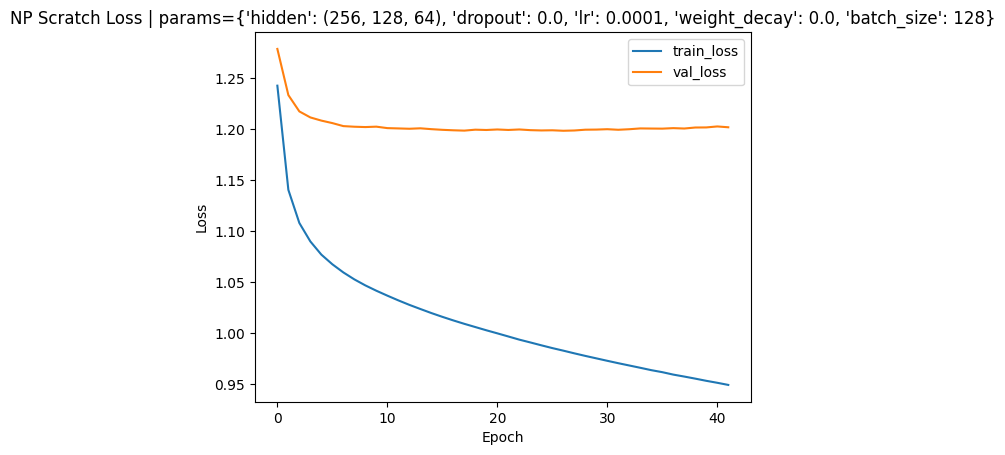

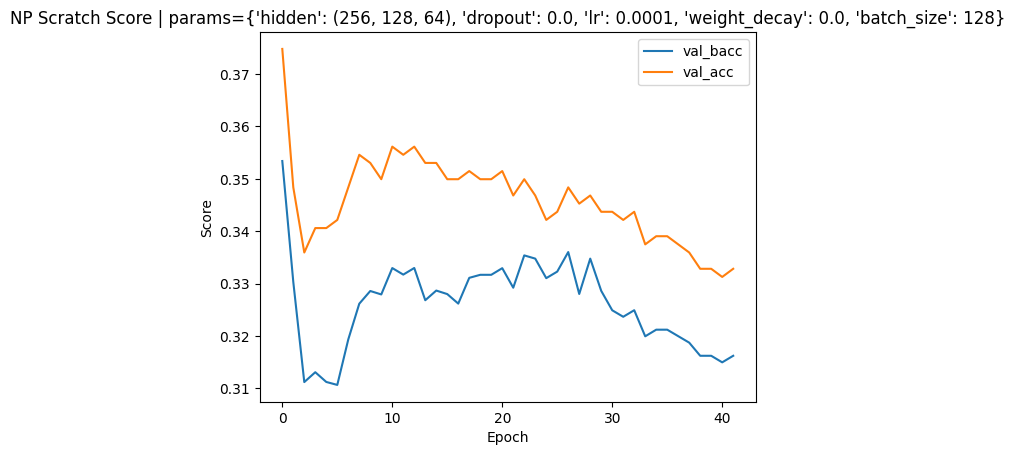

In [9]:
import os
import pickle
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, accuracy_score, balanced_accuracy_score,
    precision_recall_fscore_support
)

import matplotlib.pyplot as plt

# ============================================================
# Config
# ============================================================
CSV_PATH = "../CLASSIFY-SnP_daily_update_AMZN_features_with_target.csv"
FEATURES = ["ma_gap_20", "vol_10", "vol_20", "lower_wick", "upper_wick", "ret_1", "range_pct", "co_ret", "ret_5"]

TRAIN_RATIO = 0.8
VAL_RATIO_IN_TRAIN = 0.2

SEED = 42
np.random.seed(SEED)

# ----- Label -----
HORIZON = 7
PRICE_COL_CANDIDATES = ["Close", "Adj Close", "close", "adj_close"]
SIDEWAY_THRESHOLD = 0.01
CLASS_LABELS = {0: "Down", 1: "Sideway", 2: "Up"}
K = 3

# ----- Fixed hyperparameter (ตามที่คุณกำหนด) -----
PARAMS = {
    "hidden": (256, 128, 64),
    "dropout": 0.0,
    "lr": 1e-4,
    "weight_decay": 0.0,
    "batch_size": 128
}

# ----- Train control -----
EPOCHS = 200
PATIENCE = 15
MIN_DELTA = 1e-4  # early stop on val_loss

BATCH_SIZE_EVAL = 256
BATCH_SIZE_TEST = 256

# ----- Checkpoint (single model) -----
NP_CKPT_SINGLE = "np_ckpt_single_best.pkl"

# ============================================================
# Helpers
# ============================================================
def eval_report(name, y_true, y_pred, K=3):
    print(f"\n===== {name} =====")
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(K))
    print("\nConfusion Matrix (rows=true, cols=pred):")
    print(cm)

    acc = accuracy_score(y_true, y_pred)
    bacc = balanced_accuracy_score(y_true, y_pred)

    pr, rc, f1, sup = precision_recall_fscore_support(
        y_true, y_pred, labels=np.arange(K), zero_division=0
    )
    macro_pr, macro_rc, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )

    print("\nAccuracy:", acc)
    print("Balanced Accuracy:", bacc)
    print("\nPer-class PR/RC/F1:")
    for c in range(K):
        print(f"  {c} ({CLASS_LABELS[c]}): P={pr[c]:.3f} R={rc[c]:.3f} F1={f1[c]:.3f} Support={sup[c]}")
    print(f"\nMacro Avg: P={macro_pr:.3f} R={macro_rc:.3f} F1={macro_f1:.3f}")

def np_save(path, payload):
    with open(path, "wb") as f:
        pickle.dump(payload, f)

def np_load(path):
    with open(path, "rb") as f:
        return pickle.load(f)

# ============================================================
# NumPy blocks
# ============================================================
def relu(x):
    return np.maximum(0.0, x)

def relu_backward(dout, x):
    dx = dout.copy()
    dx[x <= 0.0] = 0.0
    return dx

def softmax(logits):
    z = logits - np.max(logits, axis=1, keepdims=True)
    exp = np.exp(z)
    return exp / (np.sum(exp, axis=1, keepdims=True) + 1e-12)

def one_hot(y, K):
    oh = np.zeros((len(y), K), dtype=np.float32)
    oh[np.arange(len(y)), y] = 1.0
    return oh

def weighted_softmax_ce_loss_and_grad(logits, y, class_weights=None):
    B, K = logits.shape
    probs = softmax(logits)

    p_true = probs[np.arange(B), y]
    loss_vec = -np.log(p_true + 1e-12)

    if class_weights is not None:
        w = class_weights[y]
        loss = np.sum(w * loss_vec) / (np.sum(w) + 1e-12)
    else:
        loss = float(np.mean(loss_vec))

    y_oh = one_hot(y, K)
    dlogits = probs - y_oh

    if class_weights is not None:
        w = class_weights[y].reshape(-1, 1)
        dlogits = (dlogits * w) / (np.sum(w) + 1e-12)
    else:
        dlogits = dlogits / B

    return float(loss), dlogits.astype(np.float32)

# ============================================================
# AdamScratch (coupled weight_decay like torch.optim.Adam)
# ============================================================
class AdamScratch:
    def __init__(self, params, lr=1e-3, betas=(0.9, 0.999), eps=1e-8, weight_decay=0.0):
        self.params = params
        self.lr = float(lr)
        self.beta1 = float(betas[0])
        self.beta2 = float(betas[1])
        self.eps = float(eps)
        self.weight_decay = float(weight_decay)
        self.t = 0
        self.m = [np.zeros_like(p) for p in self.params]
        self.v = [np.zeros_like(p) for p in self.params]

    def step(self, grads):
        self.t += 1
        b1, b2, lr, eps, wd = self.beta1, self.beta2, self.lr, self.eps, self.weight_decay

        for i, (p, g) in enumerate(zip(self.params, grads)):
            if wd != 0.0:
                g = g + wd * p  # coupled weight decay

            self.m[i] = b1 * self.m[i] + (1 - b1) * g
            self.v[i] = b2 * self.v[i] + (1 - b2) * (g * g)

            m_hat = self.m[i] / (1 - b1**self.t)
            v_hat = self.v[i] / (1 - b2**self.t)

            p -= lr * m_hat / (np.sqrt(v_hat) + eps)

# ============================================================
# MLP NumPy + Dropout
# ============================================================
class MLP_Numpy_Dropout:
    def __init__(self, in_dim, hidden=(256,128,64), dropout=0.0, out_dim=3, seed=42):
        self.rng = np.random.default_rng(seed)
        dims = [in_dim] + list(hidden) + [out_dim]

        self.W, self.b = [], []
        for i in range(len(dims) - 1):
            fan_in = dims[i]
            fan_out = dims[i + 1]
            w = self.rng.normal(0.0, np.sqrt(2.0 / fan_in), size=(fan_in, fan_out)).astype(np.float32)
            b = np.zeros((fan_out,), dtype=np.float32)
            self.W.append(w)
            self.b.append(b)

        self.dropout = float(dropout)
        self.cache = None

    def forward(self, x, training=True):
        a = x
        preacts, activs, drop_masks = [], [x], []

        for i in range(len(self.W) - 1):
            z = a @ self.W[i] + self.b[i]
            a = relu(z)

            if training and self.dropout > 0.0:
                keep_prob = 1.0 - self.dropout
                mask = (self.rng.random(a.shape) < keep_prob).astype(np.float32) / keep_prob
                a = a * mask
            else:
                mask = None

            preacts.append(z)
            activs.append(a)
            drop_masks.append(mask)

        logits = a @ self.W[-1] + self.b[-1]
        self.cache = (preacts, activs, drop_masks)
        return logits

    def backward(self, dlogits):
        preacts, activs, drop_masks = self.cache
        L = len(self.W)

        dW = [None] * L
        db = [None] * L

        a_last = activs[-1]
        dW[-1] = a_last.T @ dlogits
        db[-1] = np.sum(dlogits, axis=0)

        da = dlogits @ self.W[-1].T

        for i in reversed(range(L - 1)):
            mask = drop_masks[i]
            if mask is not None:
                da = da * mask

            z = preacts[i]
            dz = relu_backward(da, z)

            a_prev = activs[i]
            dW[i] = a_prev.T @ dz
            db[i] = np.sum(dz, axis=0)

            da = dz @ self.W[i].T

        dW = [g.astype(np.float32) for g in dW]
        db = [g.astype(np.float32) for g in db]
        return dW, db

    def params_list(self):
        return self.W + self.b

    def grads_list(self, dW, db):
        return dW + db

    def get_state(self):
        return {"W": [w.copy() for w in self.W], "b": [b.copy() for b in self.b]}

    def set_state(self, state):
        self.W = [w.copy() for w in state["W"]]
        self.b = [b.copy() for b in state["b"]]

# ============================================================
# Mini-batch (shuffle=False)
# ============================================================
def iterate_minibatches(X, y, batch_size, shuffle=False, seed=42):
    n = len(X)
    idx = np.arange(n)

    if shuffle:
        rng = np.random.default_rng(seed)
        rng.shuffle(idx)

    for start in range(0, n, batch_size):
        batch_idx = idx[start:start + batch_size]
        yield X[batch_idx], y[batch_idx]

def eval_numpy_loss_acc_bacc(model, X, y, class_weights, batch_size=256):
    losses, preds = [], []
    for xb, yb in iterate_minibatches(X, y, batch_size):
        logits = model.forward(xb, training=False)
        loss, _ = weighted_softmax_ce_loss_and_grad(logits, yb, class_weights)
        losses.append(loss)
        preds.append(np.argmax(logits, axis=1))
    y_pred = np.concatenate(preds)
    return float(np.mean(losses)), float(accuracy_score(y, y_pred)), float(balanced_accuracy_score(y, y_pred))

def predict_numpy(model, X, batch_size=256):
    preds = []
    dummy_y = np.zeros((len(X),), dtype=np.int64)
    for xb, _ in iterate_minibatches(X, dummy_y, batch_size):
        logits = model.forward(xb, training=False)
        preds.append(np.argmax(logits, axis=1))
    return np.concatenate(preds)

# ============================================================
# Load + label + split (เหมือนเดิม)
# ============================================================
df = pd.read_csv(CSV_PATH)

if "Date" in df.columns:
    d = pd.to_datetime(df["Date"], errors="coerce")
    if d.notna().all():
        df = df.loc[d.sort_values().index].reset_index(drop=True)

missing_feat = [c for c in FEATURES if c not in df.columns]
if missing_feat:
    raise ValueError(f"Missing FEATURES columns: {missing_feat}")

price_col = next((c for c in PRICE_COL_CANDIDATES if c in df.columns), None)
if price_col is None:
    raise ValueError(f"Need price column in {PRICE_COL_CANDIDATES}")

price = df[price_col].astype(float)
future_price = price.shift(-HORIZON)
future_ret = (future_price / price) - 1.0

y_all = np.full(len(df), np.nan)
y_all[future_ret >  SIDEWAY_THRESHOLD] = 2
y_all[np.abs(future_ret) <= SIDEWAY_THRESHOLD] = 1
y_all[future_ret < -SIDEWAY_THRESHOLD] = 0

data = df[FEATURES].copy()
data["y"] = y_all
data = data.dropna().reset_index(drop=True)

X = data[FEATURES].to_numpy(np.float32)
y = data["y"].to_numpy(np.int64)

N = len(X)
split_test = int(N * TRAIN_RATIO)

X_train_full, y_train_full = X[:split_test], y[:split_test]
X_test, y_test = X[split_test:], y[split_test:]

n_train_full = len(X_train_full)
split_val = int(n_train_full * (1 - VAL_RATIO_IN_TRAIN))

X_train, y_train = X_train_full[:split_val], y_train_full[:split_val]
X_val, y_val = X_train_full[split_val:], y_train_full[split_val:]

print("Class counts (train/val/test):",
      np.bincount(y_train, minlength=3),
      np.bincount(y_val, minlength=3),
      np.bincount(y_test, minlength=3))

# standardize (เหมือน torch code คุณ)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train).astype(np.float32)
X_val_sc   = scaler.transform(X_val).astype(np.float32)
X_test_sc  = scaler.transform(X_test).astype(np.float32)

# class weights (เหมือน)
train_counts = np.bincount(y_train, minlength=3).astype(np.float32)
class_weights = (train_counts.sum() / (train_counts + 1e-9))
class_weights = class_weights / class_weights.mean()
print("Class weights:", class_weights)

# ============================================================
# Train single model (early stop by val_loss, best ckpt by val_bacc)
# ============================================================
np_model = MLP_Numpy_Dropout(
    in_dim=X_train_sc.shape[1],
    hidden=PARAMS["hidden"],
    dropout=PARAMS["dropout"],
    out_dim=K,
    seed=SEED
)

np_optim = AdamScratch(
    params=np_model.params_list(),
    lr=PARAMS["lr"],
    betas=(0.9, 0.999),
    eps=1e-8,
    weight_decay=PARAMS["weight_decay"]
)

hist_train_loss = []
hist_val_loss = []
hist_val_acc = []
hist_val_bacc = []

best_state_by_bacc = None
best_val_bacc = -1.0

best_val_loss_for_earlystop = float("inf")
wait = 0

for epoch in range(1, EPOCHS + 1):
    # train epoch
    epoch_losses = []
    for xb, yb in iterate_minibatches(X_train_sc, y_train, PARAMS["batch_size"]):
        logits = np_model.forward(xb, training=True)
        loss, dlogits = weighted_softmax_ce_loss_and_grad(logits, yb, class_weights)
        dW, db = np_model.backward(dlogits)
        grads = np_model.grads_list(dW, db)
        np_optim.step(grads)
        epoch_losses.append(loss)

    train_loss = float(np.mean(epoch_losses)) if epoch_losses else float("nan")
    val_loss, val_acc, val_bacc = eval_numpy_loss_acc_bacc(np_model, X_val_sc, y_val, class_weights, batch_size=BATCH_SIZE_EVAL)

    hist_train_loss.append(train_loss)
    hist_val_loss.append(val_loss)
    hist_val_acc.append(val_acc)
    hist_val_bacc.append(val_bacc)

    # best checkpoint by val_bacc (เหมือน torch)
    if val_bacc > best_val_bacc:
        best_val_bacc = val_bacc
        best_state_by_bacc = np_model.get_state()
        np_save(NP_CKPT_SINGLE, {
            "best_val_bacc": float(best_val_bacc),
            "params": PARAMS,
            "state": best_state_by_bacc,
        })

    # early stop by val_loss (เหมือน torch)
    improved = (best_val_loss_for_earlystop - val_loss) > MIN_DELTA
    if improved:
        best_val_loss_for_earlystop = val_loss
        wait = 0
    else:
        wait += 1

    print(f"Epoch {epoch:03d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | val_bacc={val_bacc:.4f} | wait={wait}/{PATIENCE}")

    if wait >= PATIENCE:
        break

print("\nBest val_bacc:", best_val_bacc)

# restore best by val_bacc
if os.path.exists(NP_CKPT_SINGLE):
    ckpt = np_load(NP_CKPT_SINGLE)
    np_model.set_state(ckpt["state"])
    print("Loaded best checkpoint from:", NP_CKPT_SINGLE, "| best_val_bacc =", ckpt["best_val_bacc"])

# ============================================================
# Test eval
# ============================================================
np_y_pred = predict_numpy(np_model, X_test_sc, batch_size=BATCH_SIZE_TEST)
np_y_true = y_test.copy()

print("Pred distribution:", np.bincount(np_y_pred, minlength=3))
print("True distribution:", np.bincount(np_y_true, minlength=3))

eval_report("NP Scratch Single MLP (7-day ahead) TEST", np_y_true, np_y_pred, K=3)

# ============================================================
# Plot (แค่ 1 ชุด)
# ============================================================
plt.figure()
plt.plot(hist_train_loss, label="train_loss")
plt.plot(hist_val_loss, label="val_loss")
plt.title(f"NP Scratch Loss | params={PARAMS}")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure()
plt.plot(hist_val_bacc, label="val_bacc")
plt.plot(hist_val_acc, label="val_acc")
plt.title(f"NP Scratch Score | params={PARAMS}")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()
plt.show()


===== PyTorch BEST =====
Accuracy: 0.36612702366127026
Balanced Accuracy: 0.34799922299922303
Precision macro: 0.34633278598795836
Recall macro: 0.34799922299922303
F1 macro: 0.33811587942929405
Precision weighted: 0.39649549002406814
Recall weighted: 0.36612702366127026
F1 weighted: 0.3750767536540414

Full report:
              precision    recall  f1-score   support

        Down       0.34      0.26      0.30       264
     Sideway       0.19      0.34      0.24       143
          Up       0.51      0.45      0.48       396

    accuracy                           0.37       803
   macro avg       0.35      0.35      0.34       803
weighted avg       0.40      0.37      0.38       803


===== Scratch NumPy =====
Accuracy: 0.35990037359900373
Balanced Accuracy: 0.3578088578088578
Precision macro: 0.34927906126547636
Recall macro: 0.3578088578088578
F1 macro: 0.34197193258088343
Precision weighted: 0.39699512834895595
Recall weighted: 0.35990037359900373
F1 weighted: 0.3698666074609

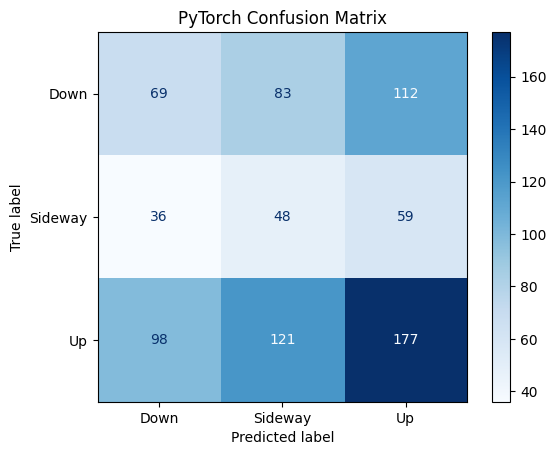

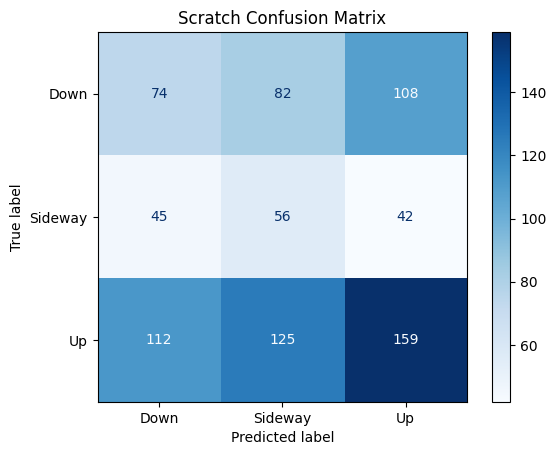

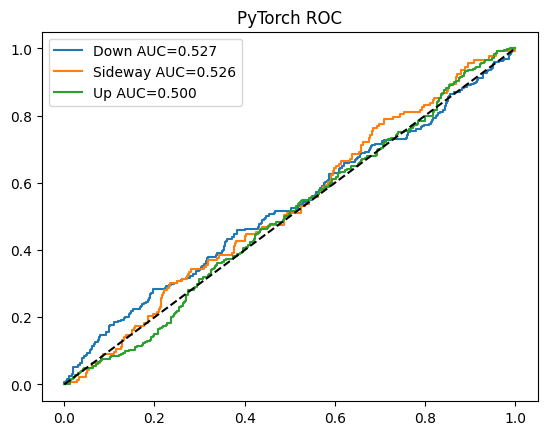

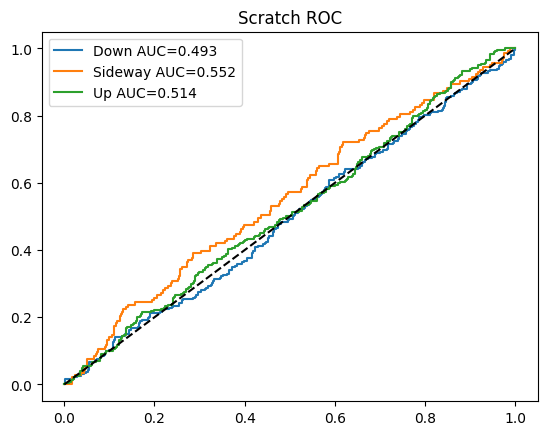

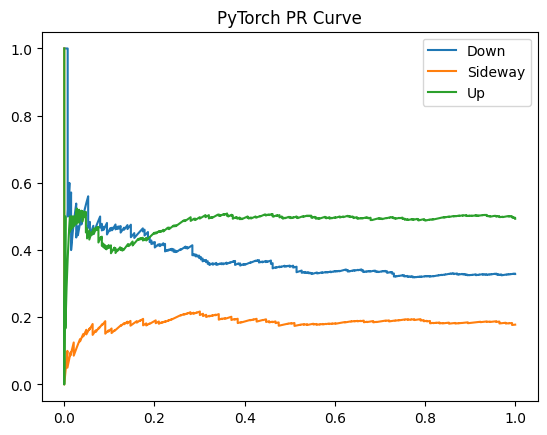

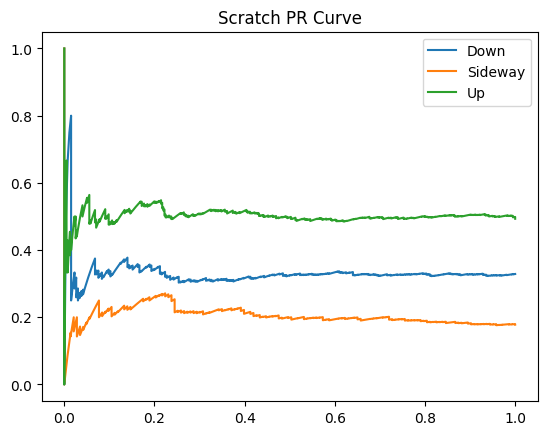

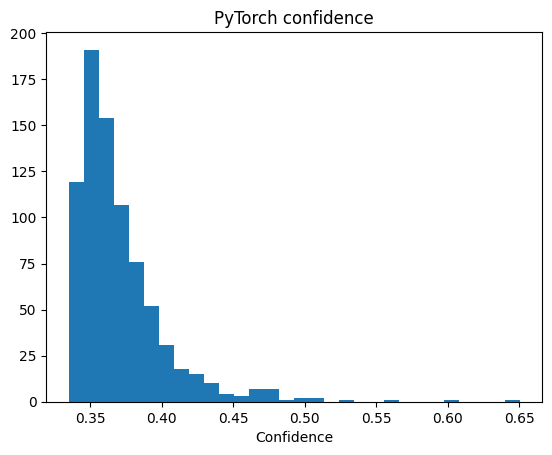

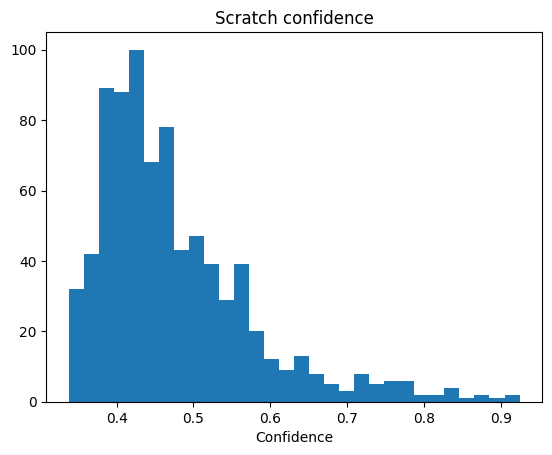

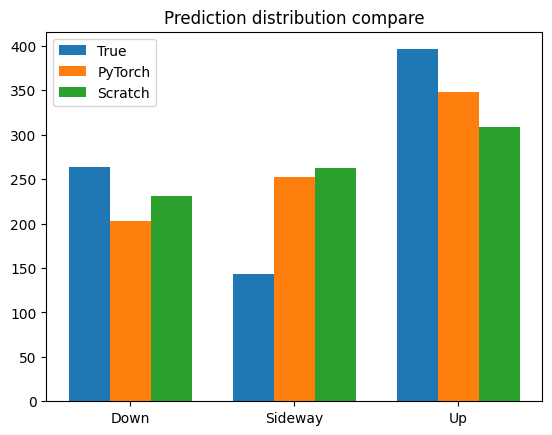

: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve,
)

from sklearn.preprocessing import label_binarize

# ============================================================
# Get probabilities and predictions
# ============================================================

def torch_predict_proba(model, loader, device):
    import torch
    model.eval()

    ys, ps, probs = [], [], []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            logits = model(xb)

            prob = torch.softmax(logits, dim=1).cpu().numpy()
            pred = np.argmax(prob, axis=1)

            probs.append(prob)
            ps.append(pred)
            ys.append(yb.numpy())

    return np.concatenate(ys), np.concatenate(ps), np.concatenate(probs)


def numpy_predict_proba(np_model, X, y, batch_size=256):

    probs = []
    preds = []

    for xb, _ in iterate_minibatches(X, y, batch_size, shuffle=False):

        logits = np_model.forward(xb)
        prob = softmax(logits)

        probs.append(prob)
        preds.append(np.argmax(prob, axis=1))

    return y.copy(), np.concatenate(preds), np.concatenate(probs)


# ============================================================
# Metrics summary
# ============================================================

def print_metrics(name, y_true, y_pred):

    print(f"\n===== {name} =====")

    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Balanced Accuracy:", balanced_accuracy_score(y_true, y_pred))

    print("Precision macro:", precision_score(y_true, y_pred, average="macro"))
    print("Recall macro:", recall_score(y_true, y_pred, average="macro"))
    print("F1 macro:", f1_score(y_true, y_pred, average="macro"))

    print("Precision weighted:", precision_score(y_true, y_pred, average="weighted"))
    print("Recall weighted:", recall_score(y_true, y_pred, average="weighted"))
    print("F1 weighted:", f1_score(y_true, y_pred, average="weighted"))

    print("\nFull report:")
    print(classification_report(
        y_true,
        y_pred,
        target_names=[CLASS_LABELS[i] for i in range(len(CLASS_LABELS))]
    ))


# ============================================================
# Confusion matrix plot
# ============================================================

def plot_confusion(y_true, y_pred, title):

    cm = confusion_matrix(y_true, y_pred)

    disp = ConfusionMatrixDisplay(
        cm,
        display_labels=[CLASS_LABELS[i] for i in range(len(CLASS_LABELS))]
    )

    disp.plot(cmap="Blues")
    plt.title(title)
    plt.show()


# ============================================================
# ROC curve (multiclass one-vs-rest)
# ============================================================

def plot_multiclass_roc(y_true, probs, title):

    y_bin = label_binarize(y_true, classes=[0,1,2])

    plt.figure()

    for i in range(3):

        fpr, tpr, _ = roc_curve(y_bin[:,i], probs[:,i])
        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, label=f"{CLASS_LABELS[i]} AUC={roc_auc:.3f}")

    plt.plot([0,1],[0,1],'k--')
    plt.title(title)
    plt.legend()
    plt.show()


# ============================================================
# Precision Recall curve
# ============================================================

def plot_pr_curve(y_true, probs, title):

    y_bin = label_binarize(y_true, classes=[0,1,2])

    plt.figure()

    for i in range(3):

        prec, rec, _ = precision_recall_curve(y_bin[:,i], probs[:,i])
        plt.plot(rec, prec, label=CLASS_LABELS[i])

    plt.title(title)
    plt.legend()
    plt.show()


# ============================================================
# Confidence histogram
# ============================================================

def plot_confidence_hist(probs, title):

    conf = probs.max(axis=1)

    plt.figure()
    plt.hist(conf, bins=30)
    plt.title(title)
    plt.xlabel("Confidence")
    plt.show()


# ============================================================
# Distribution compare
# ============================================================

def plot_distribution_compare(y_true, pred_torch, pred_np):

    x = np.arange(3)

    true_counts = np.bincount(y_true, minlength=3)
    torch_counts = np.bincount(pred_torch, minlength=3)
    np_counts = np.bincount(pred_np, minlength=3)

    width = 0.25

    plt.figure()

    plt.bar(x-width, true_counts, width, label="True")
    plt.bar(x, torch_counts, width, label="PyTorch")
    plt.bar(x+width, np_counts, width, label="Scratch")

    plt.xticks(x, [CLASS_LABELS[i] for i in range(3)])
    plt.legend()
    plt.title("Prediction distribution compare")

    plt.show()


# ============================================================
# RUN ALL EVAL
# ============================================================

torch_true, torch_pred, torch_probs = torch_predict_proba(
    best_model,
    test_loader,
    DEVICE
)

np_true, np_pred, np_probs = numpy_predict_proba(
    np_model,
    X_test_sc,
    y_test
)


# metrics
print_metrics("PyTorch BEST", torch_true, torch_pred)
print_metrics("Scratch NumPy", np_true, np_pred)


# confusion
plot_confusion(torch_true, torch_pred, "PyTorch Confusion Matrix")
plot_confusion(np_true, np_pred, "Scratch Confusion Matrix")


# ROC
plot_multiclass_roc(torch_true, torch_probs, "PyTorch ROC")
plot_multiclass_roc(np_true, np_probs, "Scratch ROC")


# PR curve
plot_pr_curve(torch_true, torch_probs, "PyTorch PR Curve")
plot_pr_curve(np_true, np_probs, "Scratch PR Curve")


# confidence
plot_confidence_hist(torch_probs, "PyTorch confidence")
plot_confidence_hist(np_probs, "Scratch confidence")


# distribution compare
plot_distribution_compare(y_test, torch_pred, np_pred)